<a href="https://colab.research.google.com/github/BE7nHgA6/Diamond-Price-Prediction-Market-Segmentation/blob/main/Diamond_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import Libraries
import numpy as np
import pandas as pd
# Load dataset
df = pd.read_csv('/content/cleaned_diamonds.csv')
df


,carat,cut,color,clarity,depth,table,x,y,z,price_inr,volume,dimension_ratio,carat_category,surface_area,price_per_carat
0,0.23,5,6,2,61.5,55.0,3.95,3.98,2.43,27058,38.202030,1.631687,1,69.9818,117643.478261
1,0.21,4,6,3,59.8,61.0,3.89,3.84,2.31,27058,34.505856,1.673160,1,65.5878,128847.619048
2,0.23,2,6,5,56.9,65.0,4.05,4.07,2.31,27141,38.076885,1.757576,1,70.4814,118004.347826
3,0.29,4,2,4,62.4,58.0,4.20,4.23,2.63,27722,46.724580,1.602662,1,79.8738,95593.103448
4,0.31,2,1,2,63.3,58.0,4.34,4.35,2.75,27805,51.917250,1.580000,1,85.5530,89693.548387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53789,0.72,5,7,3,60.8,57.0,5.75,5.76,3.50,228831,115.920000,1.644286,2,146.8100,317820.833333
53790,0.72,2,7,3,63.1,55.0,5.69,5.75,3.61,228831,118.110175,1.584488,2,148.0318,317820.833333
53791,0.70,3,7,3,62.8,60.0,5.66,5.68,3.56,228831,114.449728,1.592697,2,145.0384,326901.428571
53792,0.86,4,3,2,61.0,58.0,6.15,6.12,3.74,228831,140.766120,1.640374,2,167.0556,266082.558140


In [79]:
#view dataset
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price_inr,volume,dimension_ratio,carat_category,surface_area,price_per_carat
0,0.23,5,6,2,61.5,55.0,3.95,3.98,2.43,27058,38.202030,1.631687,1,69.9818,117643.478261
1,0.21,4,6,3,59.8,61.0,3.89,3.84,2.31,27058,34.505856,1.673160,1,65.5878,128847.619048
2,0.23,2,6,5,56.9,65.0,4.05,4.07,2.31,27141,38.076885,1.757576,1,70.4814,118004.347826
3,0.29,4,2,4,62.4,58.0,4.20,4.23,2.63,27722,46.724580,1.602662,1,79.8738,95593.103448
4,0.31,2,1,2,63.3,58.0,4.34,4.35,2.75,27805,51.917250,1.580000,1,85.5530,89693.548387


In [80]:
#check dataset shape
df.shape

(53794, 15)

In [81]:
#check column names
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z',
       'price_inr', 'volume', 'dimension_ratio', 'carat_category',
       'surface_area', 'price_per_carat'],
      dtype='object')

In [82]:
#check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   carat            53794 non-null  float64
 1   cut              53794 non-null  int64  
 2   color            53794 non-null  int64  
 3   clarity          53794 non-null  int64  
 4   depth            53794 non-null  float64
 5   table            53794 non-null  float64
 6   x                53794 non-null  float64
 7   y                53794 non-null  float64
 8   z                53794 non-null  float64
 9   price_inr        53794 non-null  int64  
 10  volume           53794 non-null  float64
 11  dimension_ratio  53794 non-null  float64
 12  carat_category   53794 non-null  int64  
 13  surface_area     53794 non-null  float64
 14  price_per_carat  53794 non-null  float64
dtypes: float64(10), int64(5)
memory usage: 6.2 MB


In [83]:
#check missing values
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
x,0
y,0
z,0
price_inr,0


In [84]:
#check duplicate values
df.duplicated().sum()

np.int64(0)

In [5]:
#remove duplicates
df.drop_duplicates(inplace=True)

In [6]:
df.shape

(53794, 15)

In [7]:
#check invalid values
(df[['x', 'y', 'z']] == 0).sum()

,0
x,0
y,0
z,0


In [8]:
#replace zero values with null
df[['x', 'y', 'z']] = df[['x', 'y', 'z']].replace(0, np.nan)

In [9]:
#missing values
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
x,0
y,0
z,0
price_inr,0


In [76]:
#fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

In [77]:
#check missing values
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
x,0
y,0
z,0
price_inr,0


In [48]:
#convert USD to INR
usd_to_inr = 83

df['price_per_carat'] = df['price_inr'] / df['carat']

In [ ]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,price_inr
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,27058
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,27058
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,27141
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,27722
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,27805


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   carat      53794 non-null  float64
 1   cut        53794 non-null  object 
 2   color      53794 non-null  object 
 3   clarity    53794 non-null  object 
 4   depth      53794 non-null  float64
 5   table      53794 non-null  float64
 6   price      53794 non-null  int64  
 7   x          53794 non-null  float64
 8   y          53794 non-null  float64
 9   z          53794 non-null  float64
 10  price_inr  53794 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 4.9+ MB


In [53]:
df.to_csv('cleaned_diamonds.csv', index=False)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

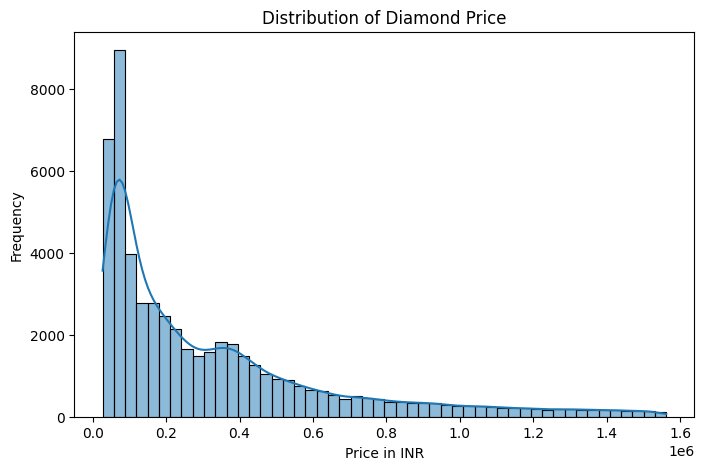

In [ ]:
#histogram price
plt.figure(figsize=(8,5))

sns.histplot(df['price_inr'], bins=50, kde=True)

plt.title('Distribution of Diamond Price')

plt.xlabel('Price in INR')

plt.ylabel('Frequency')

plt.show()

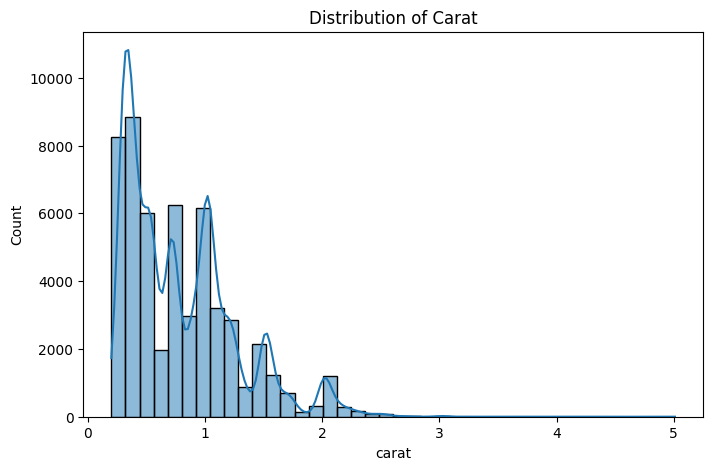

In [ ]:
#histogram for carat
plt.figure(figsize=(8,5))

sns.histplot(df['carat'], bins=40, kde=True)

plt.title('Distribution of Carat')

plt.show()

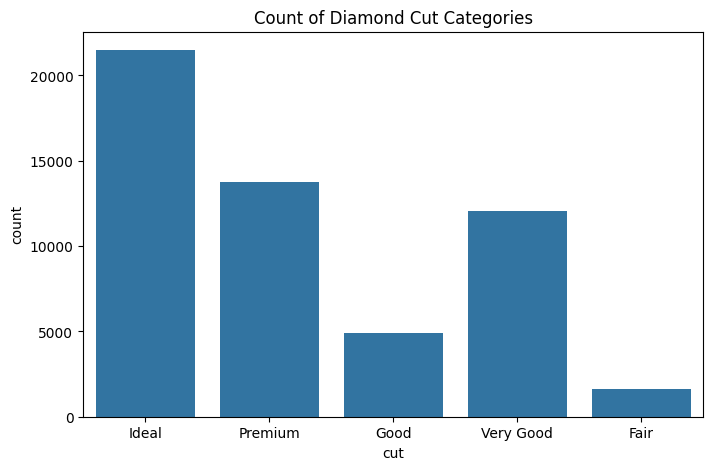

In [ ]:
#countplot for cut
plt.figure(figsize=(8,5))

sns.countplot(x='cut', data=df)

plt.title('Count of Diamond Cut Categories')

plt.show()

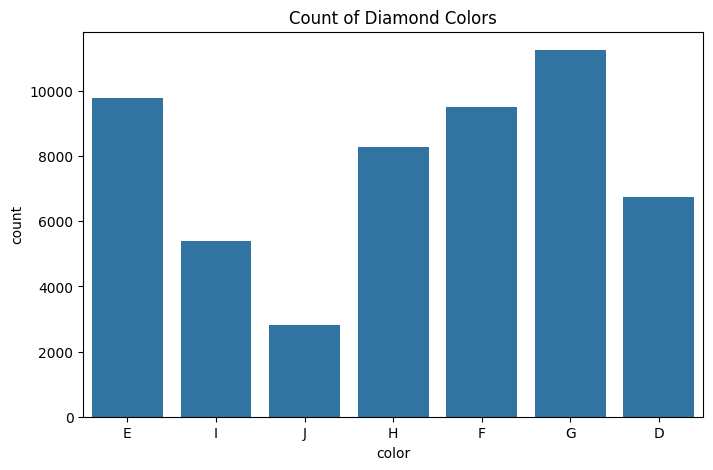

In [ ]:
#countplot for color
plt.figure(figsize=(8,5))

sns.countplot(x='color', data=df)

plt.title('Count of Diamond Colors')

plt.show()

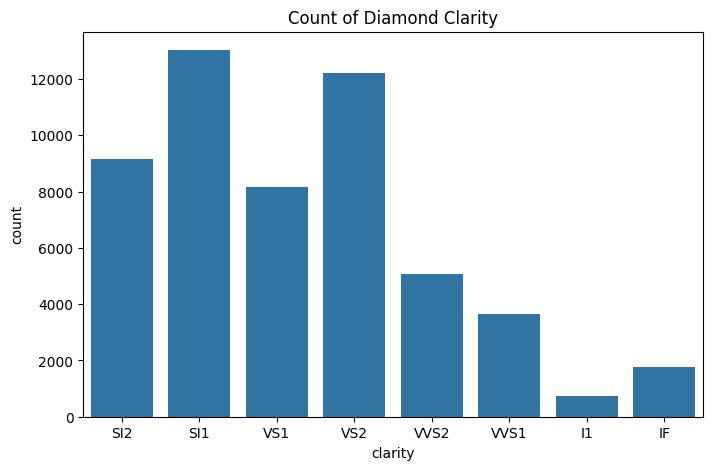

In [ ]:
#countplot for clarity
plt.figure(figsize=(8,5))

sns.countplot(x='clarity', data=df)

plt.title('Count of Diamond Clarity')

plt.show()

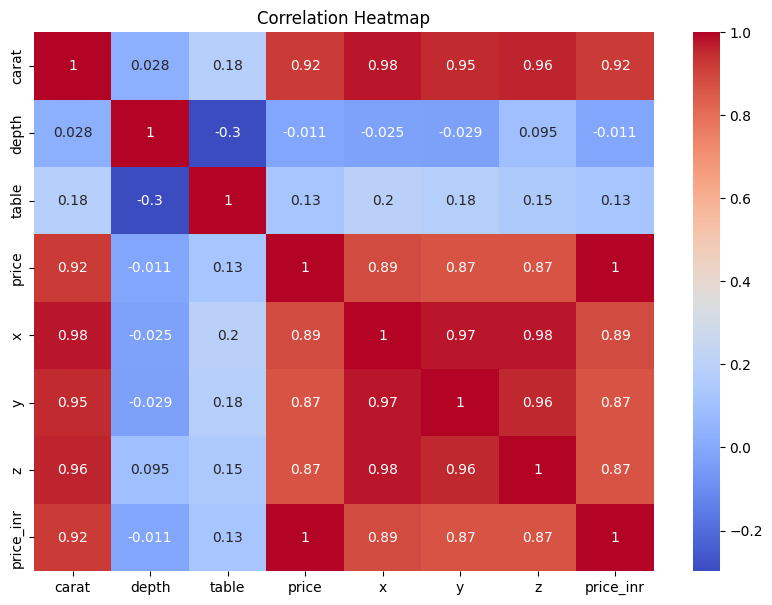

In [ ]:
#correlation heatmap
plt.figure(figsize=(10,7))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

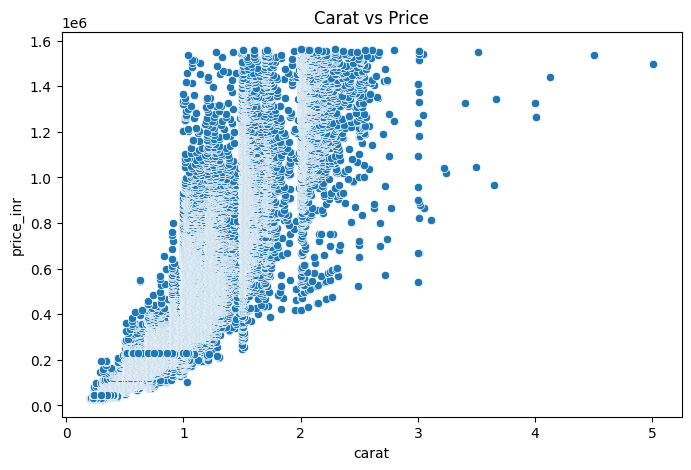

In [ ]:
#scatter plot
plt.figure(figsize=(8,5))

sns.scatterplot(x='carat', y='price_inr', data=df)

plt.title('Carat vs Price')

plt.show()

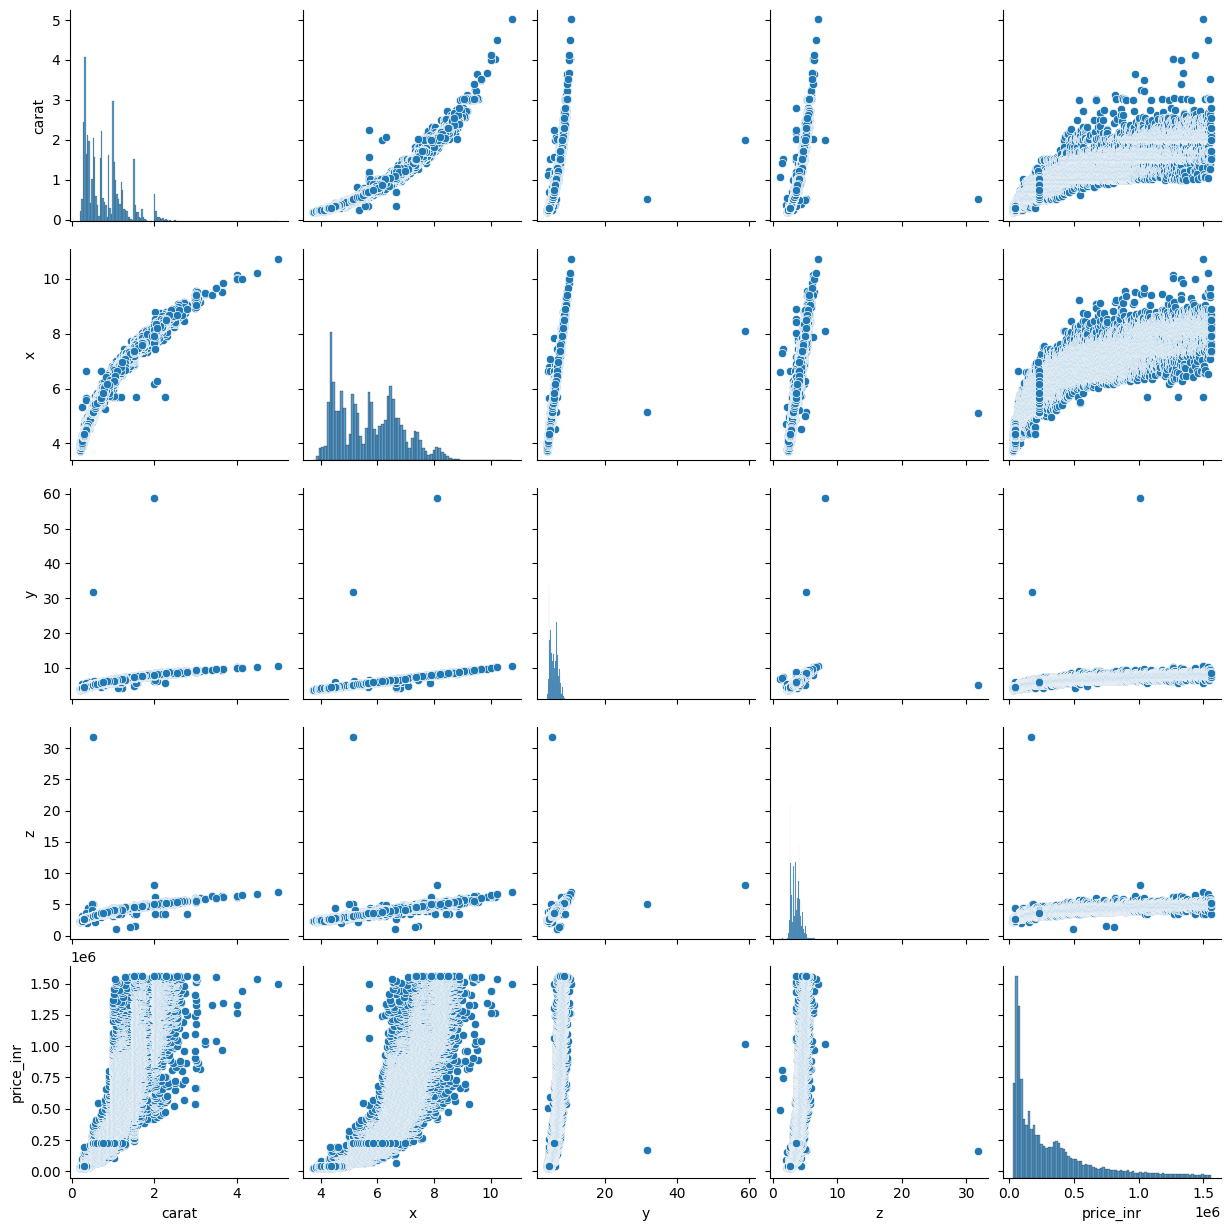

In [ ]:
#pair plot
sns.pairplot(df[['carat','x','y','z','price_inr']])

plt.show()

In [ ]:
#check for skewness
df[['carat','x','y','z','price_inr']].skew()

,0
carat,1.113651
x,0.397075
y,2.468675
z,1.589604
price_inr,1.618240


In [ ]:
#The numerical features carat, y, z, and price_inr are highly positively skewed. This indicates the presence of extreme high values and non-normal distributions.

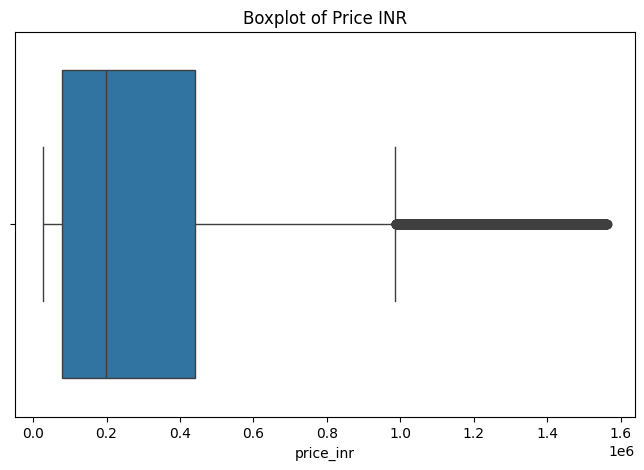

In [ ]:
#Visualize Outliers Using Boxplots
#1.Price Outlier
plt.figure(figsize=(8,5))

sns.boxplot(x=df['price_inr'])

plt.title('Boxplot of Price INR')

plt.show()

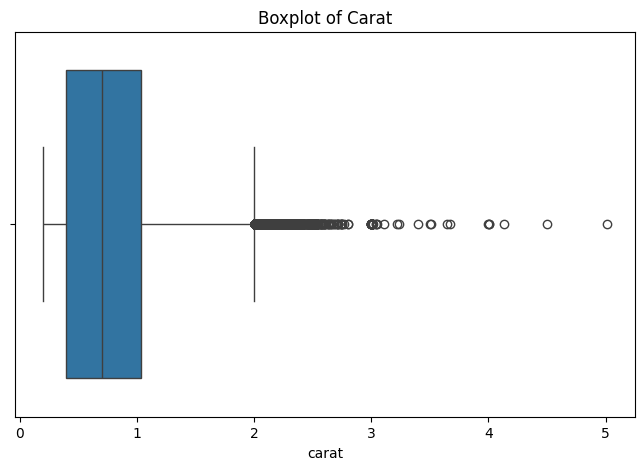

In [ ]:
#2.carat outlier
plt.figure(figsize=(8,5))

sns.boxplot(x=df['carat'])

plt.title('Boxplot of Carat')

plt.show()

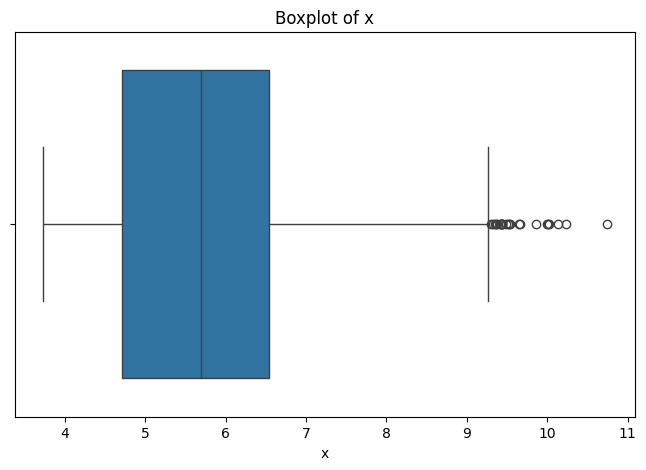

In [ ]:
#x outlier
plt.figure(figsize=(8,5))

sns.boxplot(x=df['x'])

plt.title('Boxplot of x')

plt.show()

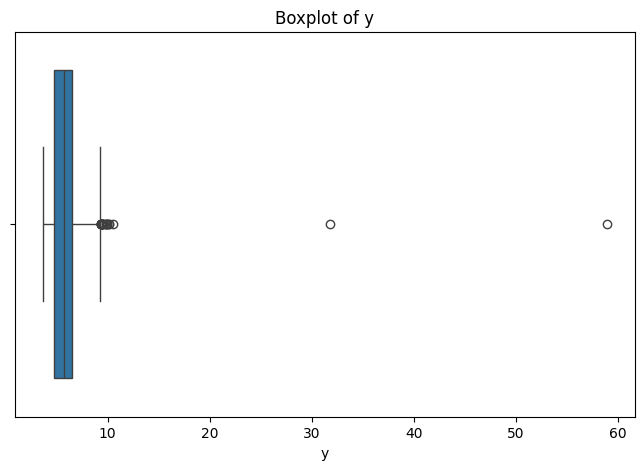

In [ ]:
#y outlier
plt.figure(figsize=(8,5))

sns.boxplot(x=df['y'])

plt.title('Boxplot of y')

plt.show()

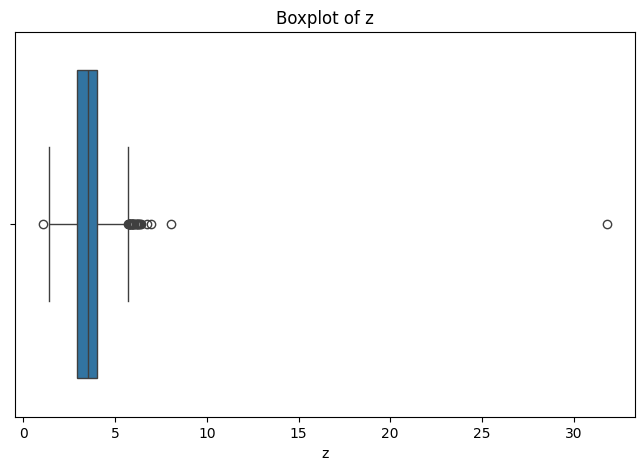

In [ ]:
#z outlier
plt.figure(figsize=(8,5))

sns.boxplot(x=df['z'])

plt.title('Boxplot of z')

plt.show()

In [ ]:
#Several numerical columns contain extreme outlier values, especially price_inr, carat, y, and z.

In [ ]:
#remove outliers using IQR method
def remove_outliers_iqr(df, columns):

    for col in columns:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    return df

In [ ]:
columns = ['carat', 'price_inr', 'x', 'y', 'z']

df = remove_outliers_iqr(df, columns)

In [ ]:
df.shape

(49387, 11)

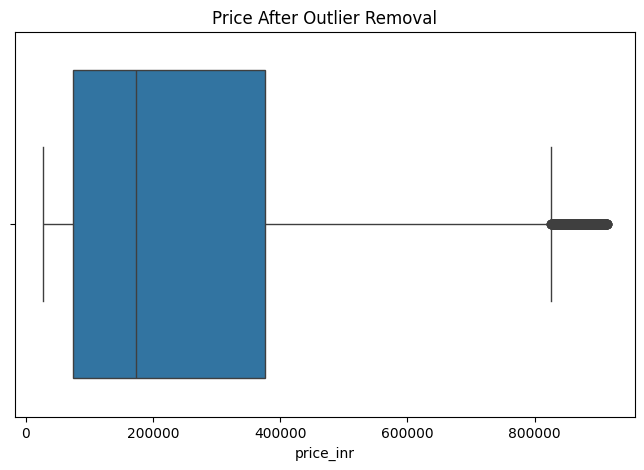

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['price_inr'])

plt.title('Price After Outlier Removal')

plt.show()

In [ ]:
#The IQR method successfully reduced the influence of extreme outlier values in the dataset.

In [ ]:
#skewness check
df[['carat','y','z','price_inr']].skew()

,0
carat,0.657400
y,0.212083
z,0.218767
price_inr,1.125583


In [ ]:
#apply log transformation
df['carat_log'] = np.log1p(df['carat'])

df['price_log'] = np.log1p(df['price_inr'])

df['y_log'] = np.log1p(df['y'])

df['z_log'] = np.log1p(df['z'])

In [ ]:
#check skewness
df[['carat_log','price_log','y_log','z_log']].skew()

,0
carat_log,0.365309
price_log,0.028626
y_log,0.039940
z_log,0.056379


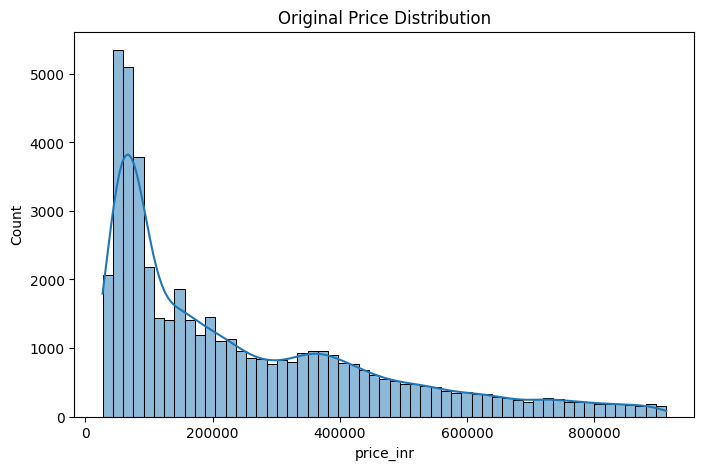

In [ ]:
#original price distribution
plt.figure(figsize=(8,5))

sns.histplot(df['price_inr'], kde=True)

plt.title('Original Price Distribution')

plt.show()

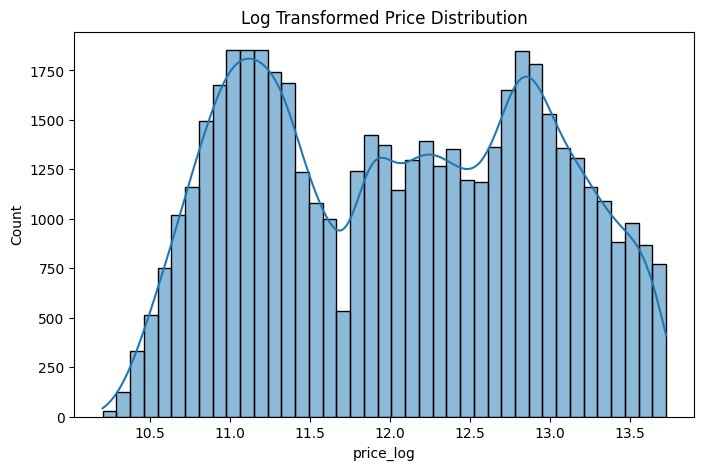

In [ ]:
#log transformed distribution
plt.figure(figsize=(8,5))

sns.histplot(df['price_log'], kde=True)

plt.title('Log Transformed Price Distribution')

plt.show()

In [ ]:
#Log transformation reduced skewness and made the distributions more normalized.

In [58]:
df.to_csv('/content/diamond_processed.csv', index=False)

In [59]:
#cretae the volume feature
df['volume'] = df['x'] * df['y'] * df['z']

In [60]:
#verify
df[['x','y','z','volume']].head()

,x,y,z,volume
0,3.95,3.98,2.43,38.202030
1,3.89,3.84,2.31,34.505856
2,4.05,4.07,2.31,38.076885
3,4.20,4.23,2.63,46.724580
4,4.34,4.35,2.75,51.917250


In [65]:
#create price per carat
df['price_per_carat'] = df['price_inr'] / df['carat']

In [66]:
#verify
df[['price_inr','carat','price_per_carat']].head()

,price_inr,carat,price_per_carat
0,27058,0.23,117643.478261
1,27058,0.21,128847.619048
2,27141,0.23,118004.347826
3,27722,0.29,95593.103448
4,27805,0.31,89693.548387


In [27]:
#create dimension ratio
df['dimension_ratio'] = (df['x'] + df['y']) / (2 * df['z'])

In [62]:
#create the function
def carat_category(carat):

    if carat < 0.5:
        return 'Light'

    elif carat < 1.5:
        return 'Medium'

    else:
        return 'Heavy'

In [63]:
#apply function
df['carat_category'] = df['carat'].apply(carat_category)

In [64]:
#verify categories
df['carat_category'].value_counts()

,count
carat_category,
Medium,29980
Light,17608
Heavy,6206


In [ ]:
#Most diamonds belong to the medium carat category, while heavy diamonds are comparatively fewer in the dataset.

In [61]:
#surface area approximation
df['surface_area'] = 2 * (
    (df['x'] * df['y']) +
    (df['y'] * df['z']) +
    (df['x'] * df['z'])
)

In [ ]:
#check new columns
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,price_inr,volume,price_per_carat,dimension_ratio,carat_category,surface_area
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,27058,38.202030,117643.478261,1.631687,Light,69.9818
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,27058,34.505856,128847.619048,1.673160,Light,65.5878
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,27141,38.076885,118004.347826,1.757576,Light,70.4814
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,27722,46.724580,95593.103448,1.602662,Light,79.8738
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,27805,51.917250,89693.548387,1.580000,Light,85.5530


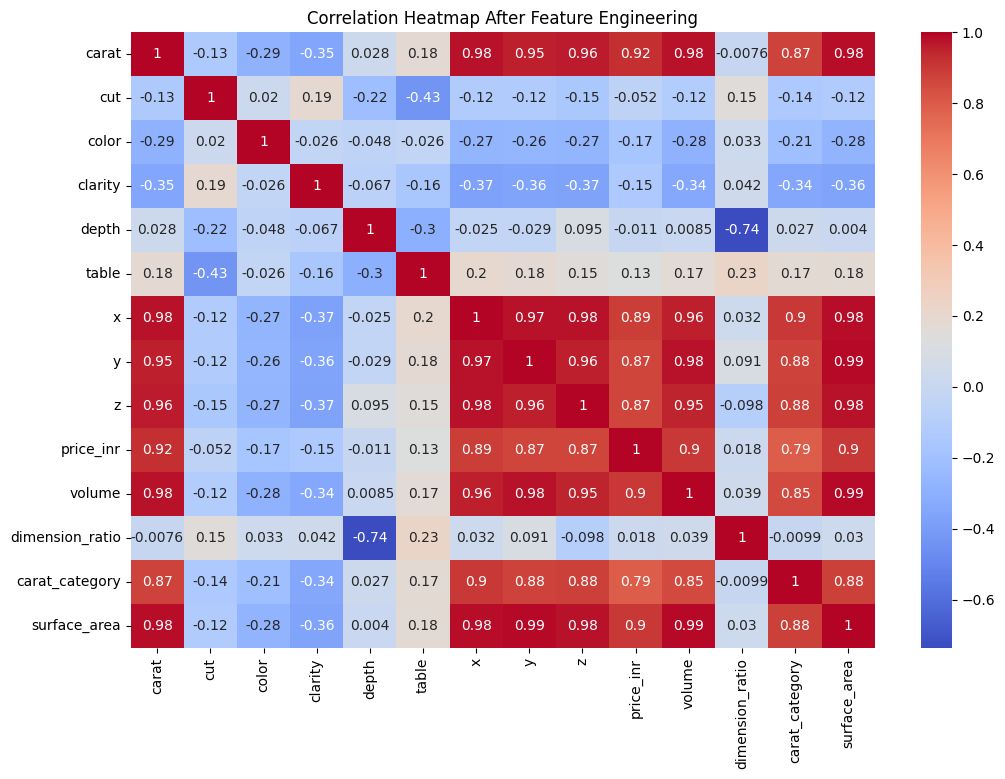

In [36]:
#check correlation with new features
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap After Feature Engineering')

plt.show()

In [22]:
df.to_csv('diamond_feature_engineered.csv', index=False)

In [68]:
#check categorical algorithms
df.select_dtypes(include='object').columns

Index(['carat_category'], dtype='object')

In [69]:
#encode cut
cut_order = {
    'Fair':1,
    'Good':2,
    'Very Good':3,
    'Premium':4,
    'Ideal':5
}

df['cut'] = df['cut'].map(cut_order)

In [56]:
#encode color
color_order = {
    'J':1,
    'I':2,
    'H':3,
    'G':4,
    'F':5,
    'E':6,
    'D':7
}

df['color'] = df['color'].map(color_order)

In [70]:
#encode clarity
clarity_order = {
    'I1':1,
    'SI2':2,
    'SI1':3,
    'VS2':4,
    'VS1':5,
    'VVS2':6,
    'VVS1':7,
    'IF':8
}

df['clarity'] = df['clarity'].map(clarity_order)

In [71]:
df.select_dtypes(include='object').columns

Index(['carat_category'], dtype='object')

In [72]:
#encode carat category
carat_cat_order = {
    'Light':1,
    'Medium':2,
    'Heavy':3
}

df['carat_category'] = df['carat_category'].map(carat_cat_order)

In [49]:
#verify encoding
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price_inr,volume,dimension_ratio,carat_category,surface_area,price_per_carat,cluster,cluster_name
0,0.23,5,6,2,61.5,55.0,3.95,3.98,2.43,27058,38.202030,1.631687,1,69.9818,117643.478261,1,Affordable Small Diamonds
1,0.21,4,6,3,59.8,61.0,3.89,3.84,2.31,27058,34.505856,1.673160,1,65.5878,128847.619048,1,Affordable Small Diamonds
2,0.23,2,6,5,56.9,65.0,4.05,4.07,2.31,27141,38.076885,1.757576,1,70.4814,118004.347826,1,Affordable Small Diamonds
3,0.29,4,2,4,62.4,58.0,4.20,4.23,2.63,27722,46.724580,1.602662,1,79.8738,95593.103448,1,Affordable Small Diamonds
4,0.31,2,1,2,63.3,58.0,4.34,4.35,2.75,27805,51.917250,1.580000,1,85.5530,89693.548387,1,Affordable Small Diamonds


In [ ]:
#Ordinal encoding was applied to categorical features based on their natural ranking order.

In [ ]:
df.drop(columns=['price'], inplace=True)

In [51]:
#define features target
X = df.drop(columns=[

    'price_inr',
    'cluster',
    'cluster_name'
])

y = df['price_inr']



In [ ]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z',
       'price_inr', 'volume', 'price_per_carat', 'dimension_ratio',
       'carat_category', 'surface_area'],
      dtype='object')

In [44]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
#scaling
#import scaler
from sklearn.preprocessing import StandardScaler

In [46]:
#create scaler
scaler = StandardScaler()

In [47]:
#scale data
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [48]:
#Random forest
from sklearn.ensemble import RandomForestRegressor

In [49]:
#train model
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

RandomForestRegressor()

In [50]:
import pickle

pickle.dump(rf, open('best_model.pkl', 'wb'))

In [51]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [52]:
!ls

 ann_diamond_model.h5	   cluster_scaler.pkl		    kmeans_model.pkl
 app.py			   diamond_feature_engineered.csv   logs.txt
 best_model.pkl		  'diamond_ml_ready (1).csv'	    nohup.out
 cleaned_diamonds.csv	   diamond_ml_ready.csv		    sample_data
 cloudflared-linux-amd64   diamond_processed.csv	    scaler.pkl


In [ ]:
#feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
6,price,9.999999e-01
4,depth,1.039586e-08
9,z,9.065388e-09
8,y,9.032067e-09
7,x,9.008420e-09
2,color,8.276679e-09
0,carat,8.241223e-09
5,table,8.018561e-09
3,clarity,6.732174e-09
1,cut,6.037741e-09


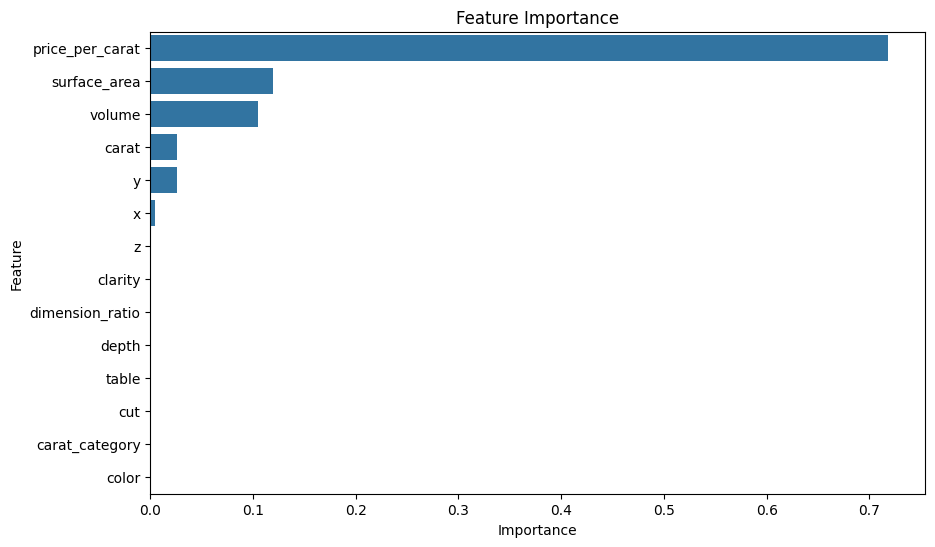

In [ ]:
#plot feature importance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

In [54]:
df.to_csv('diamond_ml_ready.csv', index=False)

In [ ]:
#Install tensor flow
!pip install tensorflow

In [15]:
#Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



In [52]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [54]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [16]:
#feature & target
X = df.drop(columns=['price_inr'])

y = df['price_inr']

In [17]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
#feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [19]:
#build ANN model
ann = Sequential([

    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),

    Dense(32, activation='relu'),

    Dense(16, activation='relu'),

    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
#compile model
ann.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [21]:
#Train ANN model
history = ann.fit(

    X_train_scaled,
    y_train,

    validation_split=0.2,

    epochs=50,

    batch_size=32,

    verbose=1
)

Epoch 1/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 126241914880.0000 - mae: 229655.9844 - val_loss: 15559099392.0000 - val_mae: 88631.8047
Epoch 2/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 11516990464.0000 - mae: 70056.8672 - val_loss: 5898956800.0000 - val_mae: 55676.6406
Epoch 3/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5940913152.0000 - mae: 44942.5117 - val_loss: 3505170432.0000 - val_mae: 39291.0078
Epoch 4/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4518182400.0000 - mae: 35777.7070 - val_loss: 2715196160.0000 - val_mae: 32551.2285
Epoch 5/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3744049408.0000 - mae: 31148.2031 - val_loss: 2348722432.0000 - val_mae: 28893.9219
Epoch 6/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3270770432.0000 - mae: 28410.8184 - val_loss: 2074782848.0000 - val_mae: 27571.3887
Epoch 7/50
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2951412992.0000 - mae: 26996.6504 - val_loss: 1929243776.

In [22]:
#predict using ANN
y_pred_ann = ann.predict(X_test_scaled)

337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [23]:
#evaluate ANN
mae = mean_absolute_error(y_test, y_pred_ann)

mse = mean_squared_error(y_test, y_pred_ann)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_ann)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 6335.84765625
MSE : 381238464.0
RMSE : 19525.328780842592
R2 Score : 0.9963692426681519


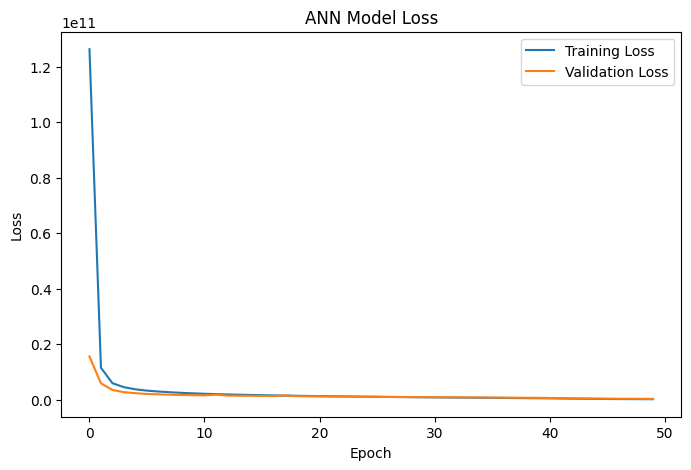

In [24]:
#plot training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('ANN Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

In [25]:
ann.save('ann_diamond_model.h5')

In [26]:
#select features for clustering
X_cluster = df.drop(columns=['price_inr'])

In [27]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

In [28]:
#Elbow method
from sklearn.cluster import KMeans

In [29]:
#calculate Inertia
inertia = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

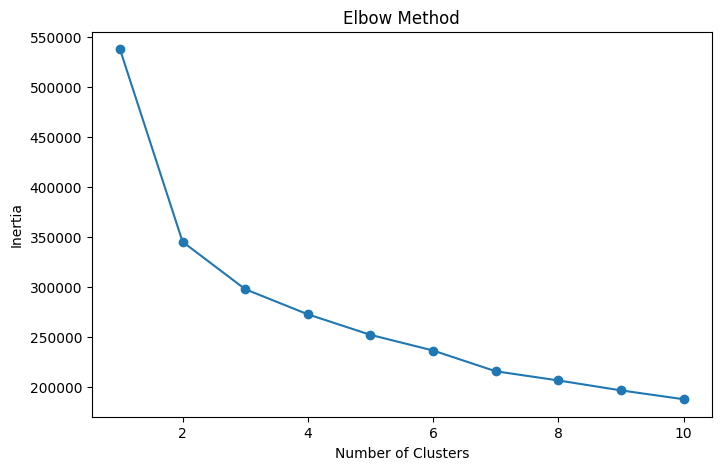

In [ ]:
#plot elbow graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title('Elbow Method')

plt.xlabel('Number of Clusters')

plt.ylabel('Inertia')

plt.show()

In [30]:
#apply kmeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

In [31]:
#add cluster column
df['cluster'] = clusters

In [32]:
#check cluster counts
df['cluster'].value_counts()

,count
cluster,
1,24523
2,22729
0,6542


In [ ]:
#silhouette score
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score :", score)

Silhouette Score : 0.250153084800537


In [33]:
#PCA
from sklearn.decomposition import PCA

In [34]:
#reduce dimensions
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

In [35]:
#create PCA dataframe
pca_df = pd.DataFrame(
    data=pca_features,
    columns=['PC1', 'PC2']
)

pca_df['cluster'] = clusters

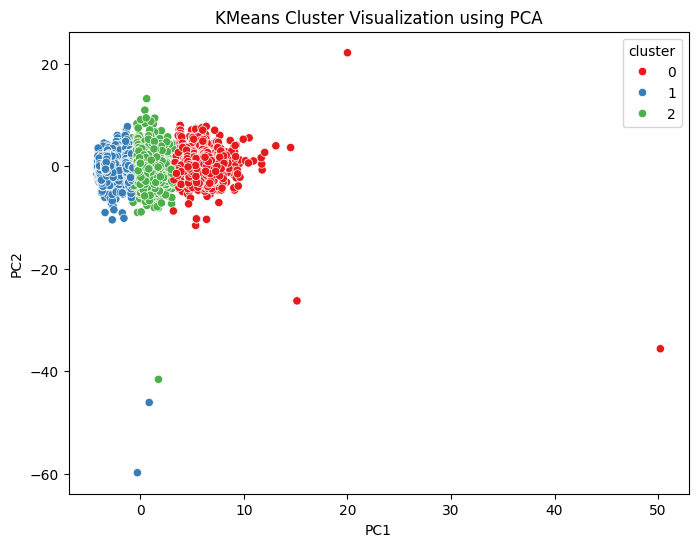

In [36]:
#cluster visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    data=pca_df,
    palette='Set1'
)

plt.title('KMeans Cluster Visualization using PCA')

plt.show()

In [37]:
cluster_names = {

    0: 'Premium Heavy Diamonds',

    1: 'Affordable Small Diamonds',

    2: 'Mid-range Balanced Diamonds'
}

In [38]:
#Map cluster names
df['cluster_name'] = df['cluster'].map(cluster_names)

In [39]:
#verify
df[['cluster', 'cluster_name']].head()

,cluster,cluster_name
0,1,Affordable Small Diamonds
1,1,Affordable Small Diamonds
2,1,Affordable Small Diamonds
3,1,Affordable Small Diamonds
4,1,Affordable Small Diamonds


In [59]:
df[['cluster', 'cluster_name']].drop_duplicates()

,cluster,cluster_name
0,1,Affordable Small Diamonds
90,2,Mid-range Balanced Diamonds
1358,0,Premium Heavy Diamonds


In [41]:
#save model
import pickle

pickle.dump(kmeans, open('kmeans_model.pkl', 'wb'))

In [42]:
#save scaler
pickle.dump(scaler, open('cluster_scaler.pkl', 'wb'))

In [43]:
#save dataset
df.to_csv('diamond_clustered.csv', index=False)

In [1]:
#streamlit
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 48.3 MB/s eta 0:00:00
--2026-05-29 13:55:51--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.5.2/cloudflared-linux-amd64 [following]
--2026-05-29 13:55:52--  https://github.com/cloudflare/cloudflared/releases/download/2026.5.2/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/49ed726b-742b-4dbe-a0cf-d9efc4d22773?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-29T14%3A53%3A32Z&rscd=attachment%3B+filename%3D

In [2]:
!pip install streamlit-option-menu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 4.2 MB/s eta 0:00:00


In [58]:
!streamlit run /content/app.py &>/content/logs.txt &

In [57]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import pickle

# Load Models
st.set_page_config(page_title="Dimension Dynamics Price Prediction & Market Segmentation", layout="wide")
#SQL query executor
st.markdown("""
    <style>

    .stApp {
        background-color:#F38BC8

    }
    h1, h2, h3 {
        font-family: 'Arial';
        color: #2c3e50;
    }
    </style>

""", unsafe_allow_html=True)


model = pickle.load(open('best_model.pkl', 'rb'))

scaler = pickle.load(open('scaler.pkl', 'rb'))

cluster_model = pickle.load(open('kmeans_model.pkl', 'rb'))

cluster_scaler = pickle.load(open('cluster_scaler.pkl', 'rb'))

# Title
st.title("💎 Diamond Price Prediction & Market Segmentation")

st.write("Enter Diamond Details")

# User Inputs
carat = st.number_input("Carat", min_value=0.1)

cut = st.selectbox(
    "Cut",
    ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
)

color = st.selectbox(
    "Color",
    ['J', 'I', 'H', 'G', 'F', 'E', 'D']
)

clarity = st.selectbox(
    "Clarity",
    ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
)

depth = st.number_input("Depth")

table = st.number_input("Table")

x = st.number_input("x dimension")

y = st.number_input("y dimension")

z = st.number_input("z dimension")

# Encoding
cut_map = {
    'Fair':1,
    'Good':2,
    'Very Good':3,
    'Premium':4,
    'Ideal':5
}

color_map = {
    'J':1,
    'I':2,
    'H':3,
    'G':4,
    'F':5,
    'E':6,
    'D':7
}

clarity_map = {
    'I1':1,
    'SI2':2,
    'SI1':3,
    'VS2':4,
    'VS1':5,
    'VVS2':6,
    'VVS1':7,
    'IF':8
}

# Convert Inputs
cut = cut_map[cut]

color = color_map[color]

clarity = clarity_map[clarity]

# Feature Engineering
volume = x * y * z

surface_area = 2 * ((x*y) + (y*z) + (x*z))

price_per_carat = 0

if z != 0:
    dimension_ratio = (x + y) / (2 * z)
else:
    dimension_ratio = 0

# Carat Category
if carat < 0.5:
    carat_category = 1

elif carat <= 1.5:
    carat_category = 2

else:
    carat_category = 3

# Final Input
features = np.array([[

    carat,
    cut,
    color,
    clarity,
    depth,
    table,
    x,
    y,
    z,
    volume,
    price_per_carat,
    dimension_ratio,
    carat_category,
    surface_area

]])

# Scale Features
features_scaled = scaler.transform(features)

cluster_scaled = cluster_scaler.transform(features)

# Predict Price
if st.button("Predict Price"):

    prediction = model.predict(features_scaled)

    st.success(f"Predicted Diamond Price (INR): ₹ {prediction[0]:,.2f}")

# Predict Cluster
if st.button("Predict Market Segment"):

    cluster = cluster_model.predict(cluster_scaled)[0]

    cluster_names = {
        0: 'Premium Heavy Diamonds',
        1: 'Affordable Small Diamonds',
        2: 'Mid-range Balanced Diamonds'
    }

    st.success(f"Market Segment: {cluster_names[cluster]}")

Overwriting app.py


In [46]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://gibraltar-addition-regulation-talented.trycloudflare.com
